Project

In [84]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
    classification_report
)
from sklearn.model_selection import GridSearchCV

In [85]:
df = pd.read_csv('data/baseline.csv')
df.head()

,SHA,cbo,wmc,dit,rfc,lcom,totalMethods,totalFields,nosi,loc,...,tryCatchQty,parenthesizedExpsQty,stringLiteralsQty,numbersQty,assignmentsQty,mathOperationsQty,variablesQty,maxNestedBlocks,uniqueWordsQty,defect
0,7a955fd6c7de2bd912be544dcfe77f9173a7aa600,5,60,2,55,189,27,5,30,247,...,4,2,47,9,27,5,17,3,191,0
1,000f1ab4780fc9460975791c52597f7c04e15be70,3,10,1,1,9,7,4,1,38,...,0,0,0,22,4,0,4,2,69,0
2,000f1ab4780fc9460975791c52597f7c04e15be71,3,10,1,1,9,7,4,0,38,...,0,0,0,22,4,0,4,2,69,1
3,0024dbdd6ba3cc7797cc0b1ae537dcdc488c4c270,20,59,3,63,189,24,9,4,262,...,0,6,6,14,45,8,41,4,222,0
4,0024dbdd6ba3cc7797cc0b1ae537dcdc488c4c271,21,58,2,61,189,24,9,0,260,...,0,6,6,14,45,8,41,4,222,1


In [86]:
print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())



Data types:
SHA                       str
cbo                     int64
wmc                     int64
dit                     int64
rfc                     int64
lcom                    int64
totalMethods            int64
totalFields             int64
nosi                    int64
loc                     int64
returnQty               int64
loopQty                 int64
comparisonsQty          int64
tryCatchQty             int64
parenthesizedExpsQty    int64
stringLiteralsQty       int64
numbersQty              int64
assignmentsQty          int64
mathOperationsQty       int64
variablesQty            int64
maxNestedBlocks         int64
uniqueWordsQty          int64
defect                  int64
dtype: object

Missing values:
SHA                     0
cbo                     0
wmc                     0
dit                     0
rfc                     0
lcom                    0
totalMethods            0
totalFields             0
nosi                    0
loc                     0
return

In [87]:
column_names = {
    "SHA": "commit_hash",
    "cbo": "coupling_between_objects",
    "wmc": "weighted_methods_per_class",
    "dit": "depth_of_inheritance_tree",
    "rfc": "response_for_class",
    "lcom": "lack_of_cohesion_in_methods",
    "totalMethods": "total_methods",
    "totalFields": "total_fields",
    "nosi": "number_of_static_invocations",
    "loc": "lines_of_code",
    "returnQty": "return_statement_count",
    "loopQty": "loop_count",
    "comparisonsQty": "comparison_count",
    "tryCatchQty": "try_catch_count",
    "parenthesizedExpsQty": "parenthesized_expression_count",
    "stringLiteralsQty": "string_literal_count",
    "numbersQty": "numeric_literal_count",
    "assignmentsQty": "assignment_count",
    "mathOperationsQty": "math_operation_count",
    "variablesQty": "variable_count",
    "maxNestedBlocks": "maximum_nested_blocks",
    "uniqueWordsQty": "unique_word_count",
    "defect": "defect"
}

df = df.rename(columns=column_names)

df.head()

,commit_hash,coupling_between_objects,weighted_methods_per_class,depth_of_inheritance_tree,response_for_class,lack_of_cohesion_in_methods,total_methods,total_fields,number_of_static_invocations,lines_of_code,...,try_catch_count,parenthesized_expression_count,string_literal_count,numeric_literal_count,assignment_count,math_operation_count,variable_count,maximum_nested_blocks,unique_word_count,defect
0,7a955fd6c7de2bd912be544dcfe77f9173a7aa600,5,60,2,55,189,27,5,30,247,...,4,2,47,9,27,5,17,3,191,0
1,000f1ab4780fc9460975791c52597f7c04e15be70,3,10,1,1,9,7,4,1,38,...,0,0,0,22,4,0,4,2,69,0
2,000f1ab4780fc9460975791c52597f7c04e15be71,3,10,1,1,9,7,4,0,38,...,0,0,0,22,4,0,4,2,69,1
3,0024dbdd6ba3cc7797cc0b1ae537dcdc488c4c270,20,59,3,63,189,24,9,4,262,...,0,6,6,14,45,8,41,4,222,0
4,0024dbdd6ba3cc7797cc0b1ae537dcdc488c4c271,21,58,2,61,189,24,9,0,260,...,0,6,6,14,45,8,41,4,222,1


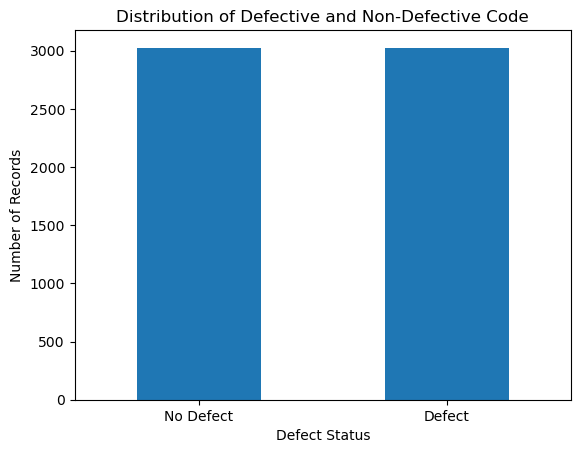

In [88]:
df["defect"].value_counts().sort_index().plot(
    kind="bar",
    title="Distribution of Defective and Non-Defective Code"
)

plt.xlabel("Defect Status")
plt.ylabel("Number of Records")
plt.xticks([0, 1], ["No Defect", "Defect"], rotation=0)
plt.show()

In [89]:
feature_df = df.drop(columns=["commit_hash", "defect"])
feature_df.describe().T

,count,mean,std,min,25%,50%,75%,max
coupling_between_objects,6052.0,27.493721,33.214827,0.0,9.0,18.0,34.00,419.0
weighted_methods_per_class,6052.0,86.177958,136.077153,0.0,18.0,45.0,100.00,1714.0
depth_of_inheritance_tree,6052.0,4.599141,9.288447,1.0,1.0,2.0,4.00,285.0
response_for_class,6052.0,68.954395,85.771623,0.0,18.0,44.0,89.00,1203.0
lack_of_cohesion_in_methods,6052.0,1242.030238,9449.009245,0.0,4.0,43.0,267.00,199855.0
total_methods,6052.0,33.497852,53.556999,0.0,8.0,17.0,39.00,758.0
total_fields,6052.0,14.049405,26.051029,0.0,3.0,7.0,18.00,903.0
number_of_static_invocations,6052.0,5.945142,25.263058,0.0,0.0,0.0,3.00,475.0
lines_of_code,6052.0,442.074190,681.566084,6.0,93.0,230.0,521.25,8832.0
return_statement_count,6052.0,25.410112,47.058370,0.0,4.0,12.0,28.00,579.0


In [90]:
X = df.drop(columns=["commit_hash", "defect"])
y = df["defect"]

In [91]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [92]:
dummy_model = DummyClassifier(
    strategy="most_frequent",
    random_state=42
)

dummy_model.fit(X_train, y_train)
dummy_predictions = dummy_model.predict(X_test)

print("Dummy Model Accuracy:",
      accuracy_score(y_test, dummy_predictions))

print("Dummy Model F1 Score:",
      f1_score(y_test, dummy_predictions, zero_division=0))

Dummy Model Accuracy: 0.4995871180842279
Dummy Model F1 Score: 0.6662995594713657


In [93]:
lr_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

lr_pipe.fit(X_train, y_train)

lr_pred = lr_pipe.predict(X_test)
lr_proba = lr_pipe.predict_proba(X_test)[:, 1]

print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.78      0.60      0.68       606
           1       0.67      0.83      0.74       605

    accuracy                           0.72      1211
   macro avg       0.73      0.72      0.71      1211
weighted avg       0.73      0.72      0.71      1211



In [94]:
print("Accuracy:",
      accuracy_score(y_test, lr_pred))

print("Precision:",
      precision_score(y_test, lr_pred))

print("Recall:",
      recall_score(y_test, lr_pred))

print("F1 Score:",
      f1_score(y_test, lr_pred))

print("ROC-AUC:",
      roc_auc_score(y_test, lr_proba))

Accuracy: 0.7151114781172585
Precision: 0.6742627345844504
Recall: 0.8314049586776859
F1 Score: 0.7446336047372317
ROC-AUC: 0.7789447126530835


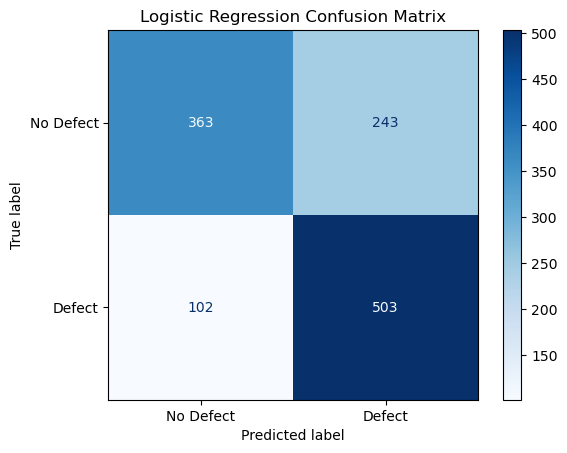

In [95]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    lr_pred,
    display_labels=["No Defect", "Defect"],
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [96]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr_pipe
        .named_steps["model"]
        .coef_[0]
})

coefficients["Absolute Coefficient"] = (
    coefficients["Coefficient"].abs()
)

coefficients = coefficients.sort_values(
    "Absolute Coefficient",
    ascending=False
)

coefficients.head(10)

,Feature,Coefficient,Absolute Coefficient
7,number_of_static_invocations,-2.233759,2.233759
2,depth_of_inheritance_tree,-0.630585,0.630585
0,coupling_between_objects,0.621650,0.621650
3,response_for_class,-0.516396,0.516396
8,lines_of_code,0.425657,0.425657
11,comparison_count,-0.284650,0.284650
9,return_statement_count,0.266654,0.266654
1,weighted_methods_per_class,0.259216,0.259216
4,lack_of_cohesion_in_methods,-0.226864,0.226864
5,total_methods,-0.179976,0.179976


In [97]:
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier
)
from sklearn.svm import SVC

In [98]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=2000,
            random_state=42
        ))
    ]),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=6,
        min_samples_leaf=10,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=300,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),

    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(
            kernel="rbf",
            probability=True,
            random_state=42
        ))
    ])
}

In [99]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

results = []

for name, model in models.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=[
            "accuracy",
            "precision",
            "recall",
            "f1",
            "roc_auc"
        ],
        n_jobs=-1
    )

    results.append({
        "Model": name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1": scores["test_f1"].mean(),
        "ROC-AUC": scores["test_roc_auc"].mean()
    })

results_df = pd.DataFrame(results).sort_values(
    "F1",
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
4,Gradient Boosting,0.785581,0.761747,0.831479,0.795042,0.833051
1,Decision Tree,0.778558,0.766415,0.801741,0.783453,0.827474
2,Random Forest,0.762445,0.747859,0.792237,0.769380,0.796097
0,Logistic Regression,0.726090,0.685075,0.838096,0.753664,0.790802
3,Extra Trees,0.719684,0.702121,0.763735,0.731599,0.735546
5,SVM,0.670724,0.619300,0.886819,0.729255,0.773565


In [100]:
tree_params = {
    "criterion": ["gini", "entropy", "log_loss"],
    "max_depth": [None, 3, 5, 7, 10, 15],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10, 20],
    "max_features": [None, "sqrt", "log2"],
    "class_weight": [None, "balanced"]
}

tree_grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=tree_params,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

tree_grid.fit(X_train, y_train)

print("Best parameters:", tree_grid.best_params_)
print("Best cross-validation F1:", tree_grid.best_score_)

Best parameters: {'class_weight': None, 'criterion': 'entropy', 'max_depth': 3, 'max_features': None, 'min_samples_leaf': 10, 'min_samples_split': 2}
Best cross-validation F1: 0.8044870364325096


In [101]:
rf_params = {
    "n_estimators": [200, 400],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 3, 5],
    "max_features": ["sqrt", "log2"]
}

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    param_grid=rf_params,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best parameters:", rf_grid.best_params_)
print("Best cross-validation F1:", rf_grid.best_score_)

Best parameters: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 10, 'n_estimators': 400}
Best cross-validation F1: 0.8079032610549033


In [102]:
gb_params_small = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [1, 2, 3],
    "min_samples_leaf": [1, 5, 10],
    "subsample": [0.8, 1.0]
}

gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid=gb_params_small,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

gb_grid.fit(X_train, y_train)

print("Best parameters:", gb_grid.best_params_)
print("Best cross-validation F1:", gb_grid.best_score_)

Best parameters: {'learning_rate': 0.05, 'max_depth': 2, 'min_samples_leaf': 1, 'n_estimators': 100, 'subsample': 0.8}
Best cross-validation F1: 0.8058657541902473


              precision    recall  f1-score   support

           0       0.81      0.71      0.76       606
           1       0.74      0.84      0.79       605

    accuracy                           0.77      1211
   macro avg       0.78      0.77      0.77      1211
weighted avg       0.78      0.77      0.77      1211

Accuracy: 0.772914946325351
Precision: 0.7412280701754386
Recall: 0.8380165289256198
F1: 0.7866563227307991
ROC-AUC: 0.8116916237078254


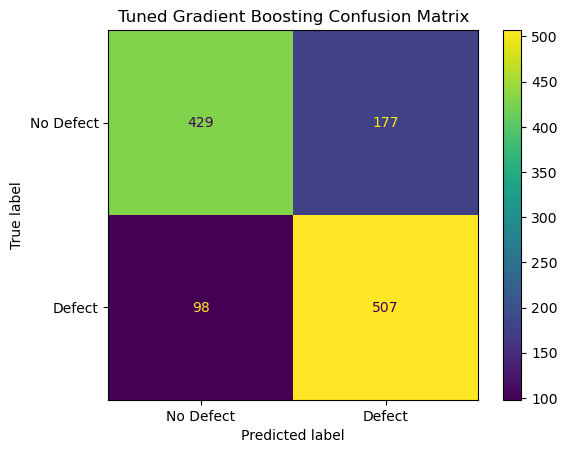

In [103]:
best_gb = gb_grid.best_estimator_

gb_predictions = best_gb.predict(X_test)
gb_probabilities = best_gb.predict_proba(X_test)[:, 1]

print(classification_report(y_test, gb_predictions))

print("Accuracy:", accuracy_score(y_test, gb_predictions))
print("Precision:", precision_score(y_test, gb_predictions))
print("Recall:", recall_score(y_test, gb_predictions))
print("F1:", f1_score(y_test, gb_predictions))
print("ROC-AUC:", roc_auc_score(y_test, gb_probabilities))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    gb_predictions,
    display_labels=["No Defect", "Defect"]
)

plt.title("Tuned Gradient Boosting Confusion Matrix")
plt.show()

In [104]:
models = {
    "Tuned Decision Tree": tree_grid.best_estimator_,
    "Tuned Random Forest": rf_grid.best_estimator_,
    "Tuned Gradient Boosting": gb_grid.best_estimator_
}

comparison = []

for name, model in models.items():
    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:, 1]

    comparison.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1": f1_score(y_test, predictions),
        "ROC-AUC": roc_auc_score(y_test, probabilities)
    })

comparison_df = pd.DataFrame(comparison).sort_values(
    "F1",
    ascending=False
)

comparison_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
1,Tuned Random Forest,0.774566,0.743402,0.838017,0.787879,0.803504
2,Tuned Gradient Boosting,0.772915,0.741228,0.838017,0.786656,0.811692
0,Tuned Decision Tree,0.754748,0.709239,0.862810,0.778523,0.800312
